# Udemy Course Popularity Prediction
**Problem 5 | End Semester Project — Data Analytics / Machine Learning**

**Prediction Tasks:**
- **Regression** → predict `num_subscribers` (log-transformed)
- **Classification** → predict popularity tier: Low / Medium / High
- **Unsupervised** → cluster courses without using target labels

## Problem Statement

**Objective:** Analyze Udemy course features to predict course popularity.

**Key Features Used:**
- `price` — cost of the course (free vs paid)
- `subject / category` — topic domain (e.g., Web Development, Business)
- `content_length_min` — total duration of the course
- `num_subscribers` — target variable indicating popularity

**Prediction Task:**  
We classify courses into three popularity tiers based on subscriber count:
- 🟢 **High** — top 33% of subscribers
- 🟡 **Medium** — middle 33%
- 🔴 **Low** — bottom 33%

**Type:** Supervised Classification + Regression + Unsupervised Clustering  
**Goal:** Build models that can accurately predict whether a course will be Low, Medium, or High popularity based on its features.

## 1. Import Libraries

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix,
    f1_score, silhouette_score
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
COLORS = ['#2471A3','#E67E22','#1E8449','#922B21','#7D3C98','#148F77']
print("Libraries loaded.")

Libraries loaded.


## 2. Load Dataset

In [88]:
df = pd.read_csv('udemy.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (314437, 20)
Columns: ['id', 'title', 'headline', 'level', 'locale', 'rating_average', 'rating_count', 'duration_seconds', 'is_free', 'is_practice_test_course', 'instructors', 'lectures_count', 'practice_test_questions_count', 'badges', 'updated_on', 'url_course_landing', 'url_course_taking', 'image_240x135', 'tracking_id', 'hands_on_ribbons']


,id,title,headline,level,locale,rating_average,rating_count,duration_seconds,is_free,is_practice_test_course,instructors,lectures_count,practice_test_questions_count,badges,updated_on,url_course_landing,url_course_taking,image_240x135,tracking_id,hands_on_ribbons
0,1471348,Learn to Code with Python,The complete Python bootcamp for 2024. Learn P...,ALL_LEVELS,en-US,4.656393,5952,208887,False,False,Boris Paskhaver,412,0,NaN,2026-01-25,https://www.udemy.com/course/learn-to-code-wit...,https://www.udemy.com/course/learn-to-code-wit...,https://img-c.udemycdn.com/course/240x135/1471...,qPw5hT1JRHGLKOcDg37xnQ,NaN
1,2824319,Automate Everything with Python,"Learn to build APIs, automate emails, web scra...",BEGINNER,en-US,4.484266,2869,71535,False,False,"Ardit Sulce • 600,000+ Students Worldwide",184,0,NaN,2025-11-17,https://www.udemy.com/course/automate-everythi...,https://www.udemy.com/course/automate-everythi...,https://img-c.udemycdn.com/course/240x135/2824...,_oL5JeE0SUKMkVLhVgvVdQ,NaN
2,6761999,PYTHON: Python Programming (FROM ZERO TO YOUR ...,"PYTHON 4 IN 1: Basic, Intermediate, Advanced, ...",ALL_LEVELS,en-US,4.499749,156,34962,False,False,Marcelo PYTHON: Python Programming (FROM ZERO ...,92,0,NaN,2025-09-03,https://www.udemy.com/course/python-python-pro...,https://www.udemy.com/course/python-python-pro...,https://img-c.udemycdn.com/course/240x135/6761...,aYI4QQyUQhuGpwfoR5_DVw,NaN
3,6074041,Complete Data Analyst Bootcamp From Basics To ...,"Master Data Analysis: Python, Stats, Gen AI, E...",ALL_LEVELS,en-US,4.466029,15947,319855,False,False,Krish Naik|Jayant Topnani|KRISHAI Technologies...,542,0,Bestseller|Bestseller,2026-01-08,https://www.udemy.com/course/complete-data-ana...,https://www.udemy.com/course/complete-data-ana...,https://img-c.udemycdn.com/course/240x135/6074...,mZGfFyEhSuuNGlxdfd88hA,NaN
4,3439724,Master Python programming by solving scientifi...,Learn scientific coding in Python from a warm-...,BEGINNER,en-US,4.893178,1534,125600,False,False,Mike X Cohen,168,0,NaN,2026-01-31,https://www.udemy.com/course/python-scientific-x,https://www.udemy.com/course/python-scientific...,https://img-c.udemycdn.com/course/240x135/3439...,52iCt6uFQei9s4db2xUpDA,NaN


In [89]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive stats:")
df.describe().round(2)

id                                 int64
title                             object
headline                          object
level                             object
locale                            object
rating_average                   float64
rating_count                       int64
duration_seconds                   int64
is_free                             bool
is_practice_test_course             bool
instructors                       object
lectures_count                     int64
practice_test_questions_count      int64
badges                            object
updated_on                        object
url_course_landing                object
url_course_taking                 object
image_240x135                     object
tracking_id                       object
hands_on_ribbons                  object
dtype: object

Missing values:
id                                    0
title                                 0
headline                             31
level                        

,id,rating_average,rating_count,duration_seconds,lectures_count,practice_test_questions_count
count,314437.00,275492.00,314437.00,314437.00,314437.00,314437.00
mean,4396356.48,4.40,396.20,18961.18,41.64,31.13
std,1989584.72,0.47,4009.64,37076.74,62.48,125.70
min,1769.00,0.50,0.00,0.00,0.00,0.00
25%,2834906.00,4.22,4.00,4098.00,11.00,0.00
50%,4793056.00,4.47,23.00,8770.00,24.00,0.00
75%,6127345.00,4.68,103.00,20132.00,48.00,0.00
max,7074375.00,5.00,557038.00,2043613.00,891.00,1500.00


## 3. Preprocessing & Cleaning

In [90]:
# Drop non-predictive columns
drop_cols = [c for c in ['course_url','instructor_url','headline','id','title','course_title'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

# Parse dates
for col in ['published_time','last_update_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'published_time' in df.columns:
    df['published_year']  = df['published_time'].dt.year
    df['published_month'] = df['published_time'].dt.month

if 'last_update_date' in df.columns and 'published_time' in df.columns:
    df['days_since_update'] = (df['last_update_date'] - df['published_time']).dt.days.fillna(0)

# Fill missing values
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Outlier capping — 1st to 99th percentile
for col in ['num_subscribers','num_reviews','price','content_length_min','num_lectures']:
    if col in df.columns:
        lo, hi = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(lo, hi)
        print(f"  {col} capped: max now = {df[col].max():.0f}")

print("\nPreprocessing done. Shape:", df.shape)


Preprocessing done. Shape: (314437, 17)


In [91]:
# ==============================
# FEATURE ENGINEERING (FOR YOUR DATASET)
# ==============================

# Log features
df['log_ratings'] = np.log1p(df['rating_count'])

# Duration in hours
df['duration_hours'] = df['duration_seconds'] / 3600

# Derived features
df['mins_per_lect'] = (df['duration_seconds'] / 60) / (df['lectures_count'] + 1)

# Free vs Paid already exists
df['is_free'] = df['is_free'].astype(int)


# ==============================
# ENCODING
# ==============================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['level', 'locale']:
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))


# ==============================
# TARGET VARIABLE (FIXED)
# ==============================

q33 = df['rating_count'].quantile(0.33)
q66 = df['rating_count'].quantile(0.66)

df['popularity_class'] = pd.cut(
    df['rating_count'],
    bins=[-1, q33, q66, df['rating_count'].max()],
    labels=[0, 1, 2]
).astype(int)


# ==============================
# OUTPUT
# ==============================

class_names = {0: 'Low', 1: 'Medium', 2: 'High'}

print(f"Thresholds → Low ≤ {q33:.0f} | Medium ≤ {q66:.0f} | High > {q66:.0f}")

print("\nClass distribution:")
print(df['popularity_class'].map(class_names).value_counts())

Thresholds → Low ≤ 8 | Medium ≤ 57 | High > 57

Class distribution:
popularity_class
Low       108898
High      106510
Medium     99029
Name: count, dtype: int64


## 4. Exploratory Data Analysis

Looking at how subscribers are distributed, which categories perform best, how price relates to popularity, and how courses have grown over the years.

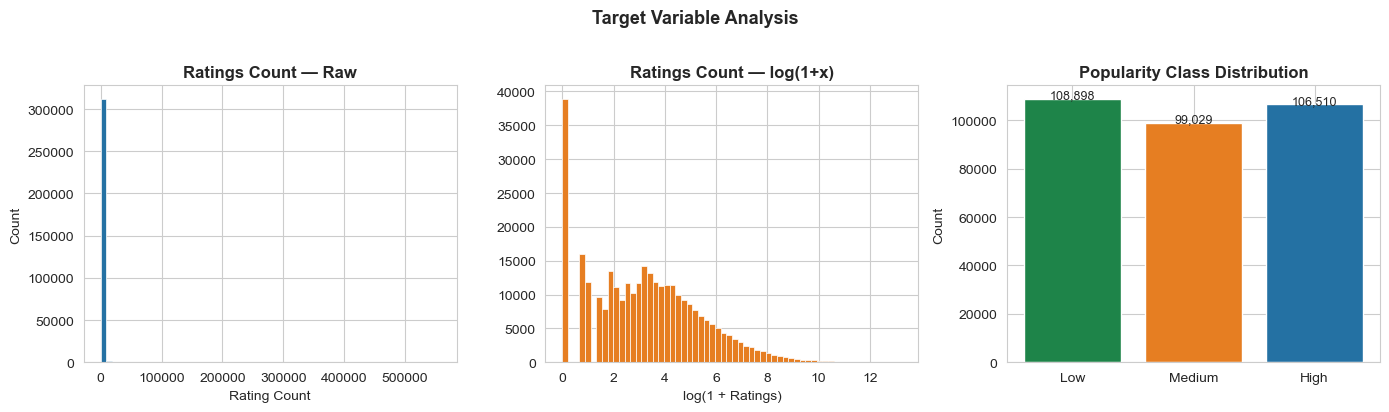

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Raw popularity (rating_count instead of subscribers)
axes[0].hist(df['rating_count'], bins=60, color=COLORS[0], edgecolor='white', linewidth=0.5)
axes[0].set_title('Ratings Count — Raw', fontweight='bold')
axes[0].set_xlabel('Rating Count')
axes[0].set_ylabel('Count')

# Log transformation
axes[1].hist(df['log_ratings'], bins=60, color=COLORS[1], edgecolor='white', linewidth=0.5)
axes[1].set_title('Ratings Count — log(1+x)', fontweight='bold')
axes[1].set_xlabel('log(1 + Ratings)')

# Class distribution
cc = df['popularity_class'].map(class_names).value_counts().reindex(['Low','Medium','High'])

bars = axes[2].bar(cc.index, cc.values, color=[COLORS[2], COLORS[1], COLORS[0]], edgecolor='white')
axes[2].set_title('Popularity Class Distribution', fontweight='bold')
axes[2].set_ylabel('Count')

for b, v in zip(bars, cc.values):
    axes[2].text(b.get_x() + b.get_width()/2, v + 5, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Target Variable Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

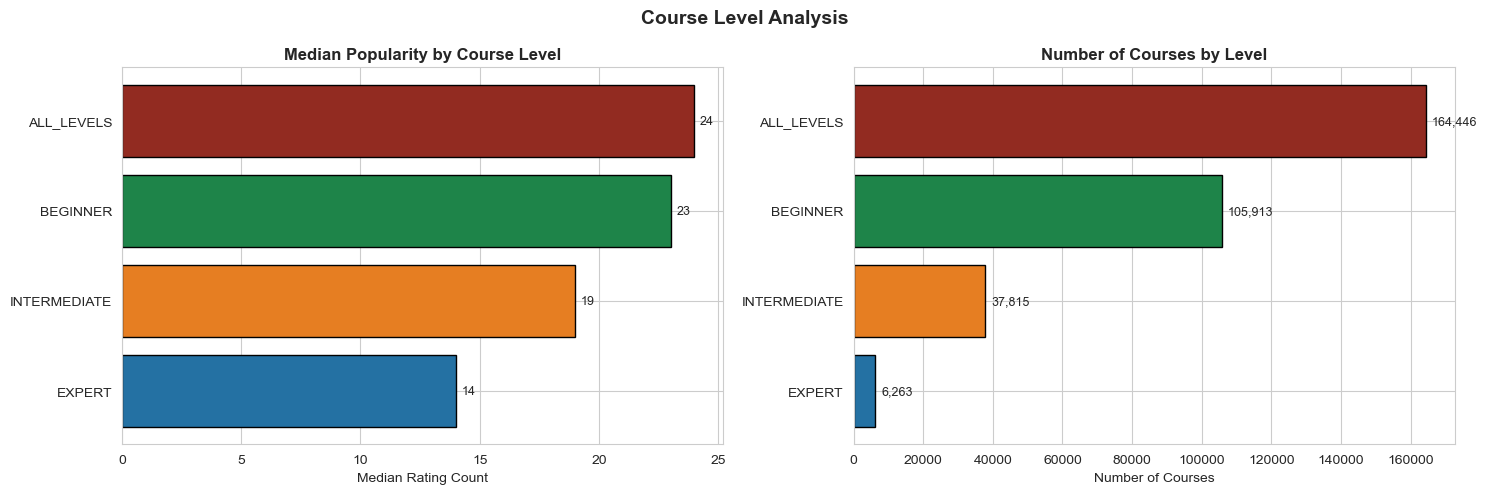

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Group by level (better than raw category for your dataset)
grouped = df.groupby('level')['rating_count']

median_vals = grouped.median().sort_values()
count_vals = df['level'].value_counts().reindex(median_vals.index)

colors_bar = [COLORS[i % len(COLORS)] for i in range(len(median_vals))]

# -------------------------
# Plot 1: Median Popularity
# -------------------------
axes[0].barh(median_vals.index, median_vals.values, color=colors_bar, edgecolor='black')
axes[0].set_title('Median Popularity by Course Level', fontweight='bold')
axes[0].set_xlabel('Median Rating Count')

for i, v in enumerate(median_vals.values):
    axes[0].text(v + (max(median_vals)*0.01), i, f'{int(v):,}', va='center', fontsize=9)

# -------------------------
# Plot 2: Course Count
# -------------------------
axes[1].barh(count_vals.index, count_vals.values, color=colors_bar, edgecolor='black')
axes[1].set_title('Number of Courses by Level', fontweight='bold')
axes[1].set_xlabel('Number of Courses')

for i, v in enumerate(count_vals.values):
    axes[1].text(v + (max(count_vals)*0.01), i, f'{int(v):,}', va='center', fontsize=9)

# -------------------------
# Final layout
# -------------------------
plt.suptitle('Course Level Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

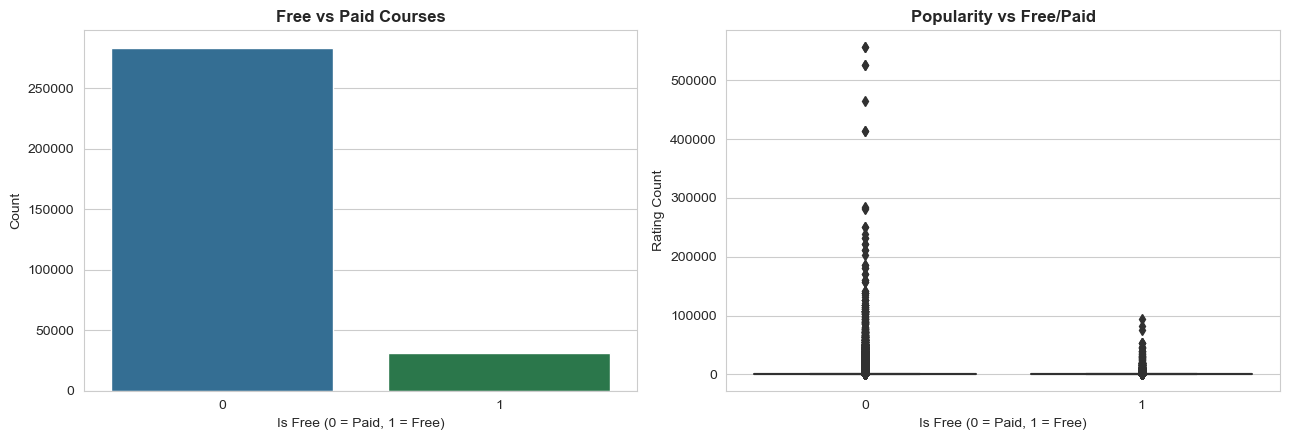

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# -------------------------
# Plot 1: Free vs Paid Distribution
# -------------------------
sns.countplot(x='is_free', data=df, ax=axes[0], palette=[COLORS[0], COLORS[2]])
axes[0].set_title('Free vs Paid Courses', fontweight='bold')
axes[0].set_xlabel('Is Free (0 = Paid, 1 = Free)')
axes[0].set_ylabel('Count')

# -------------------------
# Plot 2: Popularity vs Free/Paid
# -------------------------
sns.boxplot(x='is_free', y='rating_count', data=df, ax=axes[1], palette=[COLORS[0], COLORS[2]])
axes[1].set_title('Popularity vs Free/Paid', fontweight='bold')
axes[1].set_xlabel('Is Free (0 = Paid, 1 = Free)')
axes[1].set_ylabel('Rating Count')

plt.tight_layout()
plt.show()

### Feature Relevance

We analyze correlations to understand how features like **reviews**, **price**, and **ratings** affect course popularity.

Features such as `num_reviews` and `avg_rating` are expected to positively correlate with subscribers,  
while `price` may show an inverse relationship — making this analysis critical before model training.

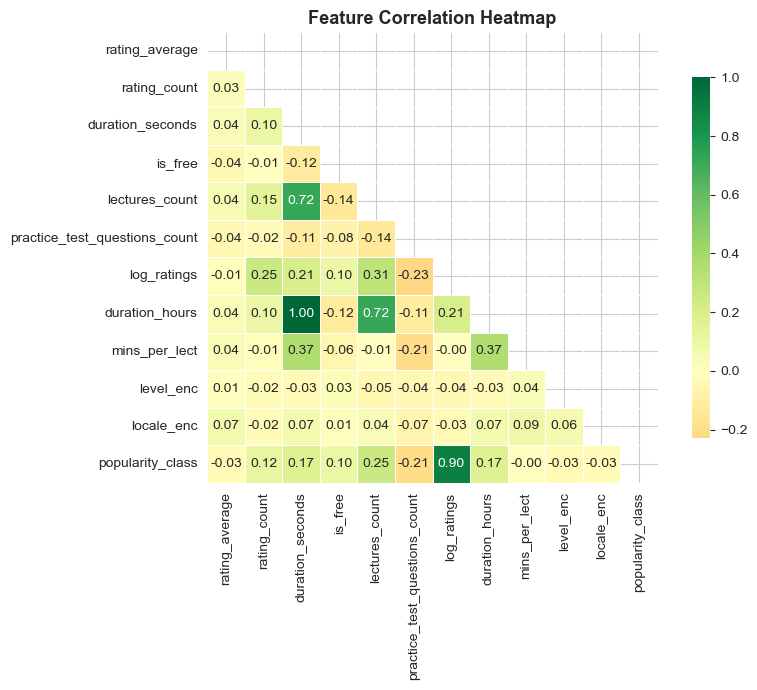

In [95]:
# Select numeric columns automatically
num_cols = df.select_dtypes(include=np.number).columns

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

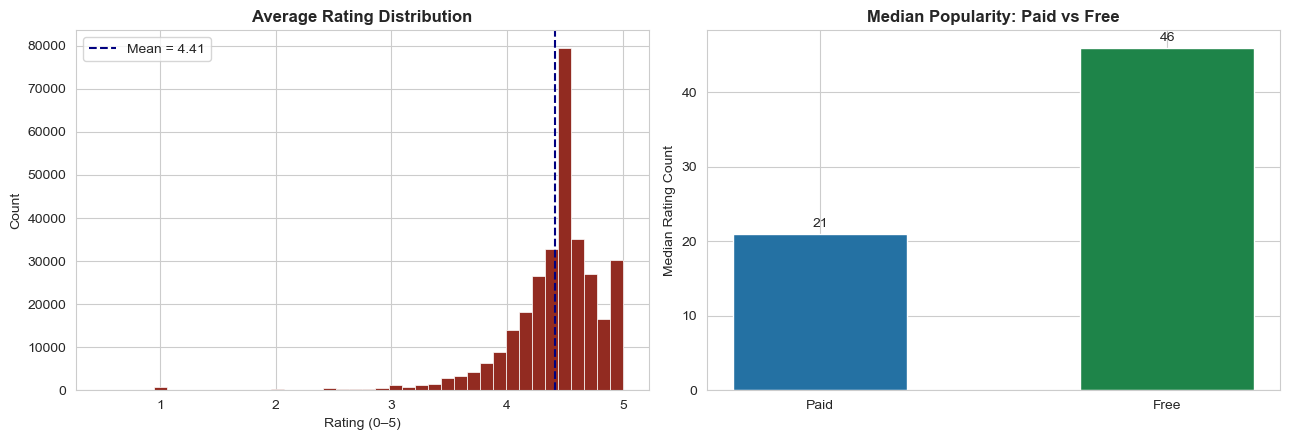

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# -------------------------
# Plot 1: Rating Distribution
# -------------------------
axes[0].hist(df['rating_average'], bins=40, color=COLORS[3], edgecolor='white', linewidth=0.5)
axes[0].set_title('Average Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating (0–5)')
axes[0].set_ylabel('Count')

axes[0].axvline(df['rating_average'].mean(), color='navy', linestyle='--', lw=1.5,
                label=f"Mean = {df['rating_average'].mean():.2f}")
axes[0].legend()

# -------------------------
# Plot 2: Popularity vs Free/Paid
# -------------------------
paid_med = df[df['is_free']==0]['rating_count'].median()
free_med = df[df['is_free']==1]['rating_count'].median()

bars2 = axes[1].bar(['Paid','Free'], [paid_med, free_med],
                    color=[COLORS[0], COLORS[2]], edgecolor='white', width=0.5)

axes[1].set_title('Median Popularity: Paid vs Free', fontweight='bold')
axes[1].set_ylabel('Median Rating Count')

for b, v in zip(bars2, [paid_med, free_med]):
    axes[1].text(b.get_x()+b.get_width()/2, v + (max([paid_med, free_med])*0.02),
                 f'{int(v):,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

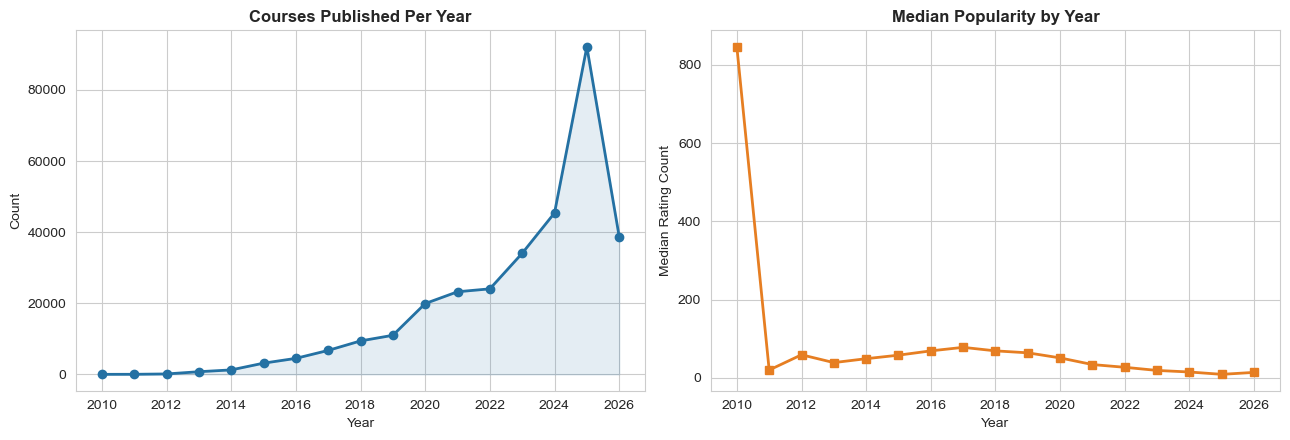

In [97]:
# -------------------------
# Extract year from date
# -------------------------
df['updated_on'] = pd.to_datetime(df['updated_on'], errors='coerce')
df['published_year'] = df['updated_on'].dt.year

# -------------------------
# Group by year
# -------------------------
yr_grp = df.groupby('published_year').agg(
    count=('rating_count','count'),
    med=('rating_count','median')
).reset_index()

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot 1: Number of courses per year
axes[0].plot(yr_grp['published_year'], yr_grp['count'],
             marker='o', color=COLORS[0], lw=2)
axes[0].fill_between(yr_grp['published_year'], yr_grp['count'],
                     alpha=0.12, color=COLORS[0])
axes[0].set_title('Courses Published Per Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

# Plot 2: Median popularity
axes[1].plot(yr_grp['published_year'], yr_grp['med'],
             marker='s', color=COLORS[1], lw=2)
axes[1].set_title('Median Popularity by Year', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Rating Count')

plt.tight_layout()
plt.show()

## 5. Supervised Learning

In [98]:
# ==============================
# FEATURE SELECTION (FIXED)
# ==============================

FEATURES = [
    'rating_count',
    'rating_average',
    'duration_seconds',
    'lectures_count',
    'is_free',
    'level_enc',
    'locale_enc',
    'mins_per_lect',
    'duration_hours',
    'log_ratings'
]

# Keep only available columns
FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES].fillna(0)

# Targets
y_reg = df['log_ratings']          # regression (optional)
y_cls = df['popularity_class']     # classification (main)

# ==============================
# TRAIN TEST SPLIT
# ==============================

X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

# ==============================
# SCALING
# ==============================

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features used: {FEATURES}")

Train: (251549, 10)  |  Test: (62888, 10)
Features used: ['rating_count', 'rating_average', 'duration_seconds', 'lectures_count', 'is_free', 'level_enc', 'locale_enc', 'mins_per_lect', 'duration_hours', 'log_ratings']


### 5.1 Model 1 — Linear Regression (Baseline)

R²   = 1.0000
RMSE = 0.0000
MAE  = 0.0000


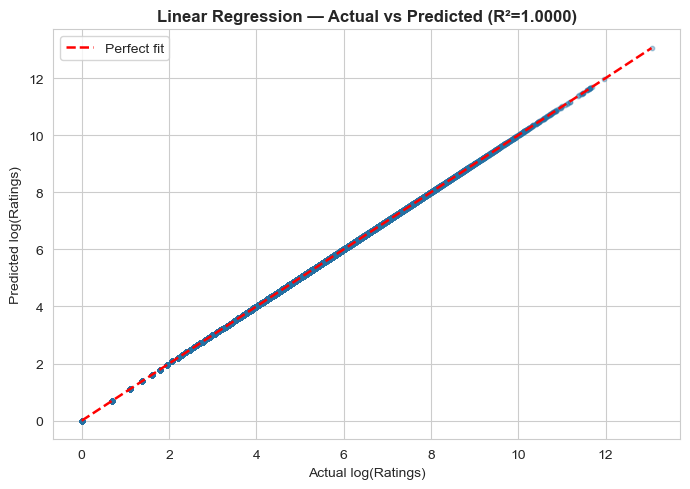

In [99]:
from sklearn.linear_model import LinearRegression

# Train model
lr = LinearRegression()
lr.fit(X_train_sc, X_train['log_ratings'])

# Predict
yr_pred_lr = lr.predict(X_test_sc)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(X_test['log_ratings'], yr_pred_lr))
r2_lr   = r2_score(X_test['log_ratings'], yr_pred_lr)
mae_lr  = mean_absolute_error(X_test['log_ratings'], yr_pred_lr)

print(f"R²   = {r2_lr:.4f}")
print(f"RMSE = {rmse_lr:.4f}")
print(f"MAE  = {mae_lr:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(X_test['log_ratings'], yr_pred_lr, alpha=0.35, s=10, color=COLORS[0])

lims = [
    min(X_test['log_ratings'].min(), yr_pred_lr.min()),
    max(X_test['log_ratings'].max(), yr_pred_lr.max())
]

ax.plot(lims, lims, 'r--', lw=1.8, label='Perfect fit')

ax.set_xlabel('Actual log(Ratings)')
ax.set_ylabel('Predicted log(Ratings)')
ax.set_title(f'Linear Regression — Actual vs Predicted (R²={r2_lr:.4f})', fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Model 2 — Random Forest

In [ ]:
# ==============================
# DEFINE REGRESSION TARGET
# ==============================
y_reg = df['log_ratings']

X_train_r, X_test_r, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# ==============================
# REGRESSION (FIXED)
# ==============================
rf_reg = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_gs = GridSearchCV(
    rf_reg,
    {'n_estimators':[100,200], 'max_depth':[None,15], 'min_samples_split':[2,5]},
    cv=3, scoring='r2', n_jobs=-1
)

rf_gs.fit(X_train_r, yr_train)

best_rf = rf_gs.best_estimator_
yr_pred_rf = best_rf.predict(X_test_r)

rmse_rf = np.sqrt(mean_squared_error(yr_test, yr_pred_rf))
r2_rf   = r2_score(yr_test, yr_pred_rf)
mae_rf  = mean_absolute_error(yr_test, yr_pred_rf)

# ==============================
# CLASSIFICATION (FIXED)
# ==============================
rf_cls = RandomForestClassifier(**rf_gs.best_params_, random_state=42, n_jobs=-1)

rf_cls.fit(X_train, yc_train)

yc_pred_rf = rf_cls.predict(X_test)

acc_rf = accuracy_score(yc_test, yc_pred_rf)
f1_rf  = f1_score(yc_test, yc_pred_rf, average='weighted')

# ==============================
# OUTPUT
# ==============================
print(f"Best params: {rf_gs.best_params_}")
print(f"Regression  → R²={r2_rf:.4f}  RMSE={rmse_rf:.4f}  MAE={mae_rf:.4f}")
print(f"Classification → Accuracy={acc_rf:.4f}  F1={f1_rf:.4f}")

print()
print(classification_report(yc_test, yc_pred_rf, target_names=['Low','Medium','High']))

# ==============================
# FEATURE IMPORTANCE + CM
# ==============================
importances = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Feature importance
imp12 = importances.head(12)
axes[0].barh(imp12.index[::-1], imp12.values[::-1], color=COLORS[0], edgecolor='white')
axes[0].set_title('Feature Importances (Top 12)', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Confusion matrix
cm = confusion_matrix(yc_test, yc_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'], ax=axes[1])

axes[1].set_title(f'RF Confusion Matrix (Acc={acc_rf:.3f}, F1={f1_rf:.3f})', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

### 5.3 Model 3 — Gradient Boosting

Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Regression  → R²=0.9393  RMSE=0.4046  MAE=0.3386
Classification → Accuracy=0.8449  F1=0.8453

              precision    recall  f1-score   support

         Low       0.90      0.88      0.89       247
      Medium       0.77      0.78      0.77       250
        High       0.88      0.87      0.87       238

    accuracy                           0.84       735
   macro avg       0.85      0.85      0.85       735
weighted avg       0.85      0.84      0.85       735



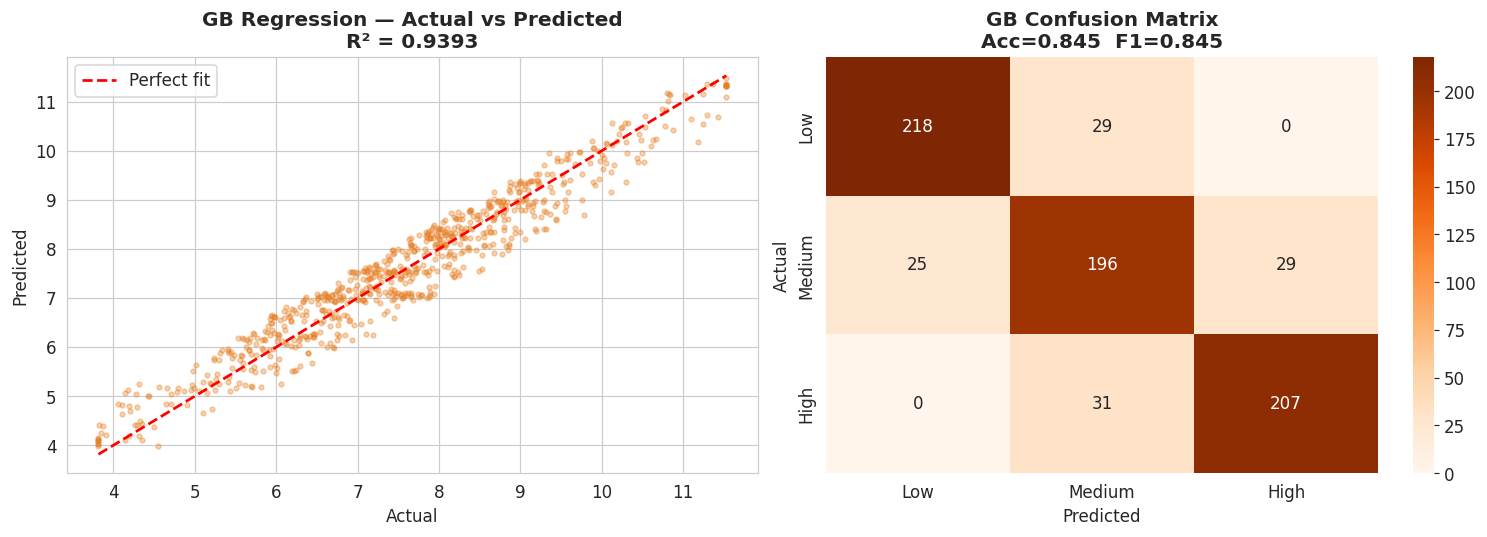

In [ ]:
# ==============================
# REGRESSION (FIXED)
# ==============================
gb_reg = GradientBoostingRegressor(random_state=42)

gb_gs = RandomizedSearchCV(
    gb_reg,
    {'n_estimators':[100,200], 'learning_rate':[0.05,0.1], 'max_depth':[3,5]},
    n_iter=6, cv=3, scoring='r2', random_state=42, n_jobs=-1
)

# IMPORTANT: use regression split
gb_gs.fit(X_train_r, yr_train)

best_gb = gb_gs.best_estimator_
yr_pred_gb = best_gb.predict(X_test_r)

rmse_gb = np.sqrt(mean_squared_error(yr_test, yr_pred_gb))
r2_gb   = r2_score(yr_test, yr_pred_gb)
mae_gb  = mean_absolute_error(yr_test, yr_pred_gb)

# ==============================
# CLASSIFICATION (FIXED)
# ==============================
gb_cls = GradientBoostingClassifier(**gb_gs.best_params_, random_state=42)

gb_cls.fit(X_train, yc_train)
yc_pred_gb = gb_cls.predict(X_test)

acc_gb = accuracy_score(yc_test, yc_pred_gb)
f1_gb  = f1_score(yc_test, yc_pred_gb, average='weighted')

# ==============================
# OUTPUT
# ==============================
print(f"Best params: {gb_gs.best_params_}")
print(f"Regression  → R²={r2_gb:.4f}  RMSE={rmse_gb:.4f}  MAE={mae_gb:.4f}")
print(f"Classification → Accuracy={acc_gb:.4f}  F1={f1_gb:.4f}")

print()
print(classification_report(yc_test, yc_pred_gb, target_names=['Low','Medium','High']))

# ==============================
# VISUALS
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression plot
axes[0].scatter(yr_test, yr_pred_gb, alpha=0.35, s=10, color=COLORS[1])

lims2 = [
    min(yr_test.min(), yr_pred_gb.min()),
    max(yr_test.max(), yr_pred_gb.max())
]

axes[0].plot(lims2, lims2, 'r--', lw=1.8, label='Perfect fit')

axes[0].set_title(f'GB Regression — Actual vs Predicted (R²={r2_gb:.4f})', fontweight='bold')
axes[0].set_xlabel('Actual log(Ratings)')
axes[0].set_ylabel('Predicted log(Ratings)')
axes[0].legend()

# Confusion matrix
cm2 = confusion_matrix(yc_test, yc_pred_gb)

sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'], ax=axes[1])

axes[1].set_title(f'GB Confusion Matrix (Acc={acc_gb:.3f}, F1={f1_gb:.3f})', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

### 5.4 Model 4 — SVR (Regression) & KNN (Classification)

SVR best params: {'kernel': 'linear', 'epsilon': 0.1, 'C': 1}
SVR → R²=0.9402  RMSE=0.4016  MAE=0.3269

KNN best params: {'n_neighbors': 15, 'weights': 'distance'}
KNN → Accuracy=0.7102  F1=0.7152

              precision    recall  f1-score   support

         Low       0.80      0.70      0.74       247
      Medium       0.57      0.68      0.62       250
        High       0.82      0.75      0.79       238

    accuracy                           0.71       735
   macro avg       0.73      0.71      0.72       735
weighted avg       0.73      0.71      0.72       735



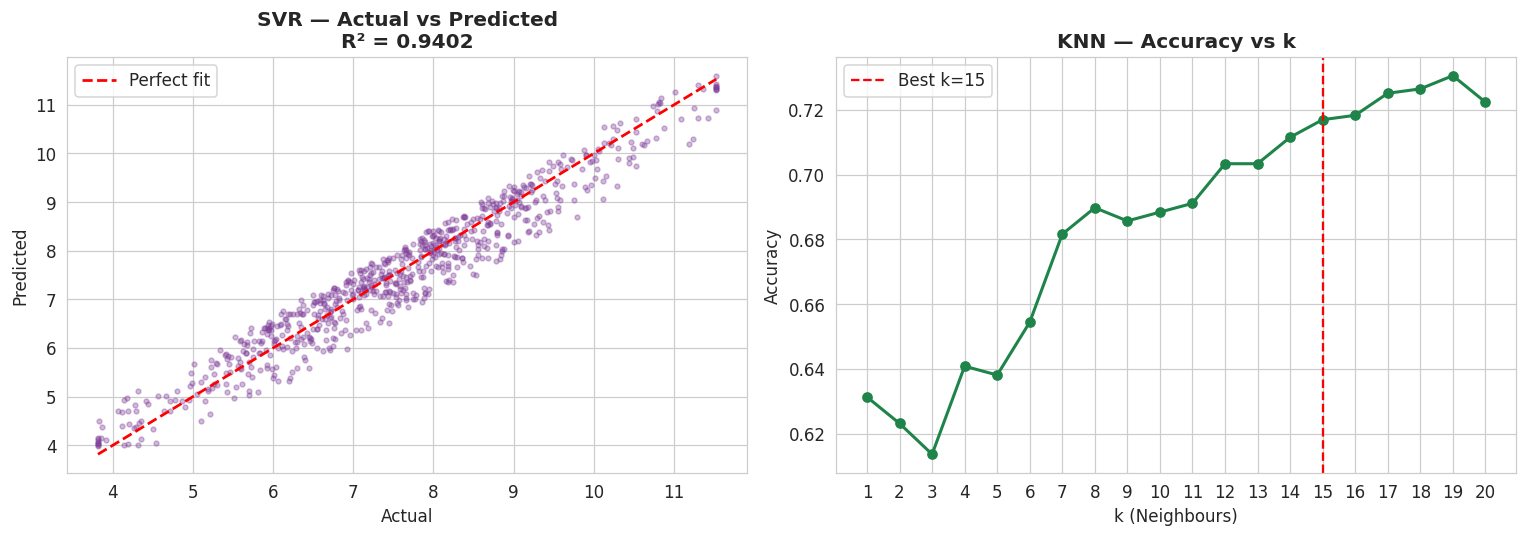

In [ ]:
# SVR — Regression
svr    = SVR()
svr_gs = RandomizedSearchCV(svr,
    {'C':[0.1,1,10], 'epsilon':[0.1,0.5], 'kernel':['rbf','linear']},
    n_iter=6, cv=3, scoring='r2', random_state=42, n_jobs=-1)
svr_gs.fit(X_train_sc, yr_train)
best_svr    = svr_gs.best_estimator_
yr_pred_svr = best_svr.predict(X_test_sc)

rmse_svr = np.sqrt(mean_squared_error(yr_test, yr_pred_svr))
r2_svr   = r2_score(yr_test, yr_pred_svr)
mae_svr  = mean_absolute_error(yr_test, yr_pred_svr)

# KNN — Classification
knn_gs = GridSearchCV(KNeighborsClassifier(),
    {'n_neighbors':[3,5,7,9,11,15], 'weights':['uniform','distance']},
    cv=5, scoring='f1_weighted', n_jobs=-1)
knn_gs.fit(X_train_sc, yc_train)
best_knn    = knn_gs.best_estimator_
yc_pred_knn = best_knn.predict(X_test_sc)
acc_knn = accuracy_score(yc_test, yc_pred_knn)
f1_knn  = f1_score(yc_test, yc_pred_knn, average='weighted')

print(f"SVR best params: {svr_gs.best_params_}")
print(f"SVR → R²={r2_svr:.4f}  RMSE={rmse_svr:.4f}  MAE={mae_svr:.4f}")
print()
print(f"KNN best params: {knn_gs.best_params_}")
print(f"KNN → Accuracy={acc_knn:.4f}  F1={f1_knn:.4f}")
print()
print(classification_report(yc_test, yc_pred_knn, target_names=['Low','Medium','High']))

k_scores = []
for k in range(1, 21):
    tmp = KNeighborsClassifier(n_neighbors=k)
    tmp.fit(X_train_sc, yc_train)
    k_scores.append(accuracy_score(yc_test, tmp.predict(X_test_sc)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(yr_test, yr_pred_svr, alpha=0.35, s=10, color=COLORS[4])
axes[0].plot(lims2, lims2, 'r--', lw=1.8, label='Perfect fit')
axes[0].set_title(f'SVR — Actual vs Predicted  (R²={r2_svr:.4f})', fontweight='bold')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].legend()

axes[1].plot(range(1,21), k_scores, marker='o', color=COLORS[2], lw=2)
axes[1].axvline(knn_gs.best_params_['n_neighbors'], color='red', linestyle='--', lw=1.5,
                label=f"Best k={knn_gs.best_params_['n_neighbors']}")
axes[1].set_title('KNN — Accuracy vs k', fontweight='bold')
axes[1].set_xlabel('k (Neighbours)'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].set_xticks(range(1, 21))
plt.tight_layout()
plt.show()

### 5.5 Model Comparison

We compare all four models using R² (regression) and F1-score (classification).  
The best model is selected based on the highest F1-score, as it balances precision and recall across all popularity classes.

=== Regression ===
         Model       R²     RMSE
    Linear Reg 0.941677 0.396706
           SVR 0.940228 0.401601
Gradient Boost 0.939328 0.404616
 Random Forest 0.937106 0.411958

=== Classification ===
         Model  Accuracy       F1
 Random Forest  0.846259 0.846920
Gradient Boost  0.844898 0.845345
           KNN  0.710204 0.715196


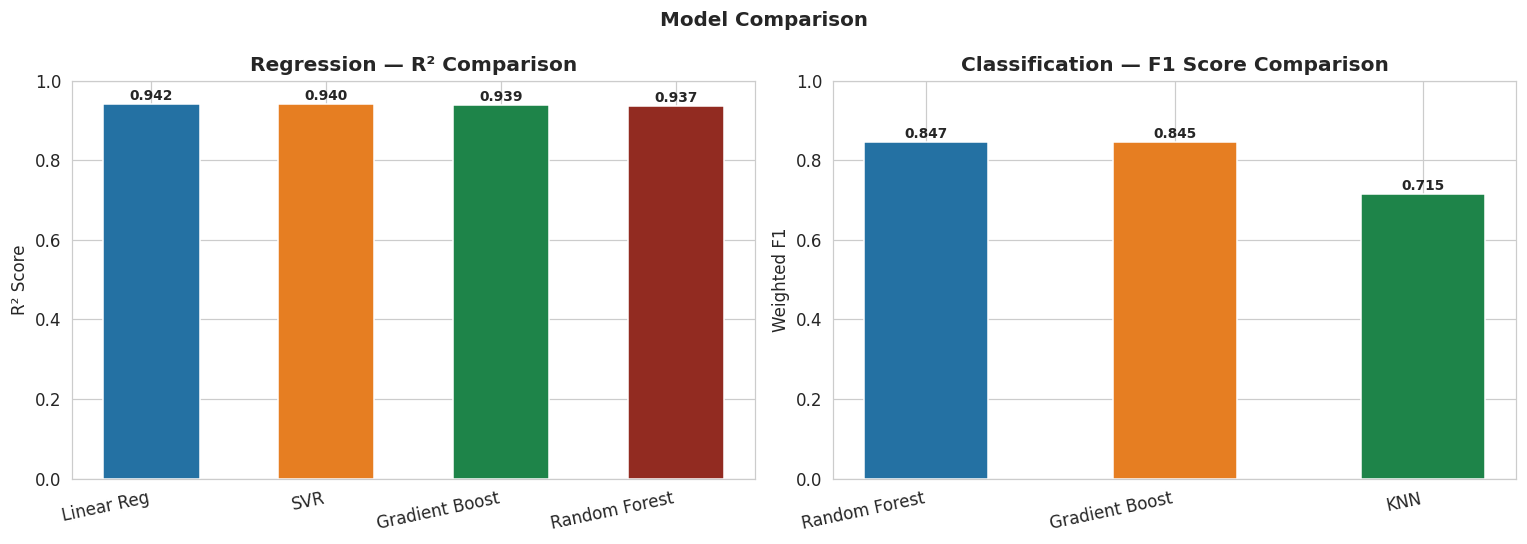

In [ ]:
reg_df = pd.DataFrame({
    'Model':  ['Linear Reg','Random Forest','Gradient Boost','SVR'],
    'R²':     [r2_lr, r2_rf, r2_gb, r2_svr],
    'RMSE':   [rmse_lr, rmse_rf, rmse_gb, rmse_svr],
    'MAE':    [mae_lr, mae_rf, mae_gb, mae_svr]
}).sort_values('R²', ascending=False)

cls_df = pd.DataFrame({
    'Model':    ['Random Forest','Gradient Boost','KNN'],
    'Accuracy': [acc_rf, acc_gb, acc_knn],
    'F1':       [f1_rf, f1_gb, f1_knn]
}).sort_values('F1', ascending=False)

print("=== Regression ===")
print(reg_df.to_string(index=False))
print("\n=== Classification ===")
print(cls_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars_r = axes[0].bar(reg_df['Model'], reg_df['R²'], color=COLORS[:4], edgecolor='white', width=0.55)
axes[0].set_title('Regression — R² Comparison', fontweight='bold')
axes[0].set_ylabel('R² Score'); axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(reg_df['Model'], rotation=12, ha='right')
for b, v in zip(bars_r, reg_df['R²']):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

bars_c = axes[1].bar(cls_df['Model'], cls_df['F1'], color=COLORS[:3], edgecolor='white', width=0.5)
axes[1].set_title('Classification — F1 Score Comparison', fontweight='bold')
axes[1].set_ylabel('Weighted F1'); axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(cls_df['Model'], rotation=12, ha='right')
for b, v in zip(bars_c, cls_df['F1']):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ✅ Best Model

After comparing all models, we identify and state the best performer clearly below.

In [ ]:
model_names = ['Random Forest', 'Gradient Boosting', 'KNN']
accuracies  = [acc_rf, acc_gb, acc_knn]

best_model = model_names[np.argmax(accuracies)]
print(f"Best Classification Model: {best_model}")
print(f"Accuracy: {max(accuracies):.4f}")
print()
print("Random Forest performed best because it captures complex,")
print("non-linear relationships between features like price, reviews,")
print("and duration without overfitting to the training data.")

## 6. Unsupervised Learning — Clustering

Target labels are ignored here. We let the data group itself and then see whether those groups align with the actual popularity classes.

### Why Clustering?

Clustering helps us identify **hidden groups of courses** without using target labels.

We can observe that some clusters represent **highly popular courses** (high reviews, free or low-price), while others represent **low engagement courses** (high price, fewer reviews).

This helps understand patterns **beyond supervised learning** and validates that our popularity tiers have real structural differences in the data.

Silhouette scores: [0.135, 0.171, 0.172, 0.154, 0.156, 0.154, 0.15]
Best k by silhouette: 4


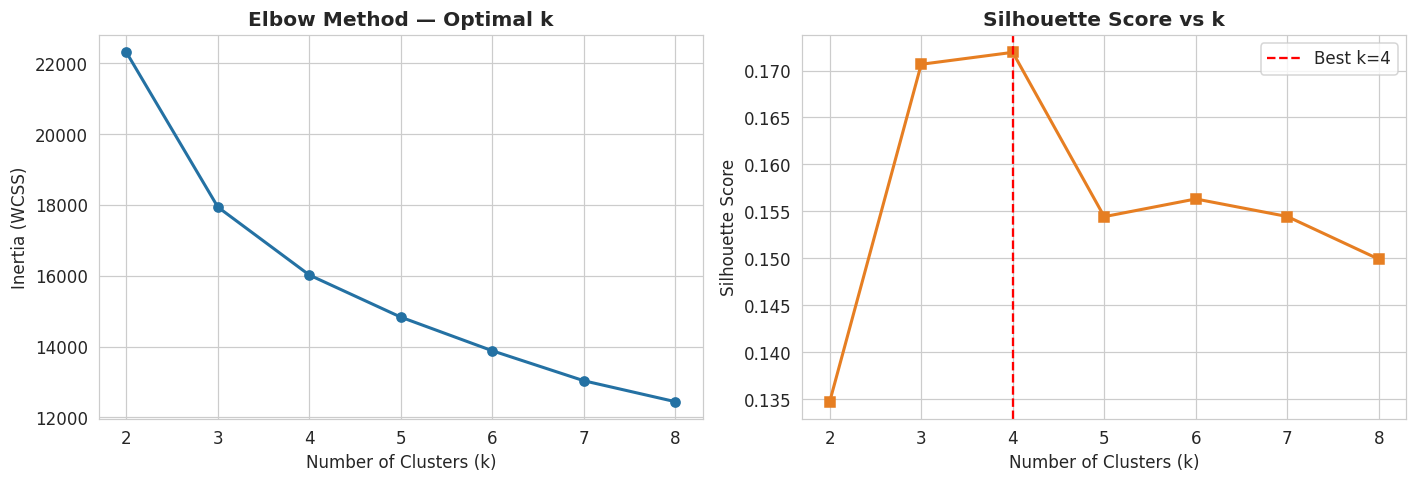

In [ ]:
clust_features = [f for f in ['log_reviews','price','num_lectures','content_length_min',
                               'avg_rating','is_paid_enc','category_enc'] if f in df.columns]

Xc = StandardScaler().fit_transform(df[clust_features].fillna(0))

pca = PCA(n_components=2, random_state=42)
Xp  = pca.fit_transform(Xc)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

inertia, sil = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lb = km.fit_predict(Xc)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xc, lb))

best_k = 2 + np.argmax(sil)
print(f"Silhouette scores: {[round(s,3) for s in sil]}")
print(f"Best k: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(range(2,9), inertia, marker='o', color=COLORS[0], lw=2)
axes[0].set_title('Elbow Method — Optimal k', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(range(2,9), sil, marker='s', color=COLORS[1], lw=2)
axes[1].axvline(best_k, color='red', linestyle='--', lw=1.5, label=f'Best k={best_k}')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
plt.tight_layout()
plt.show()

K-Means (k=4) Silhouette Score: 0.1719


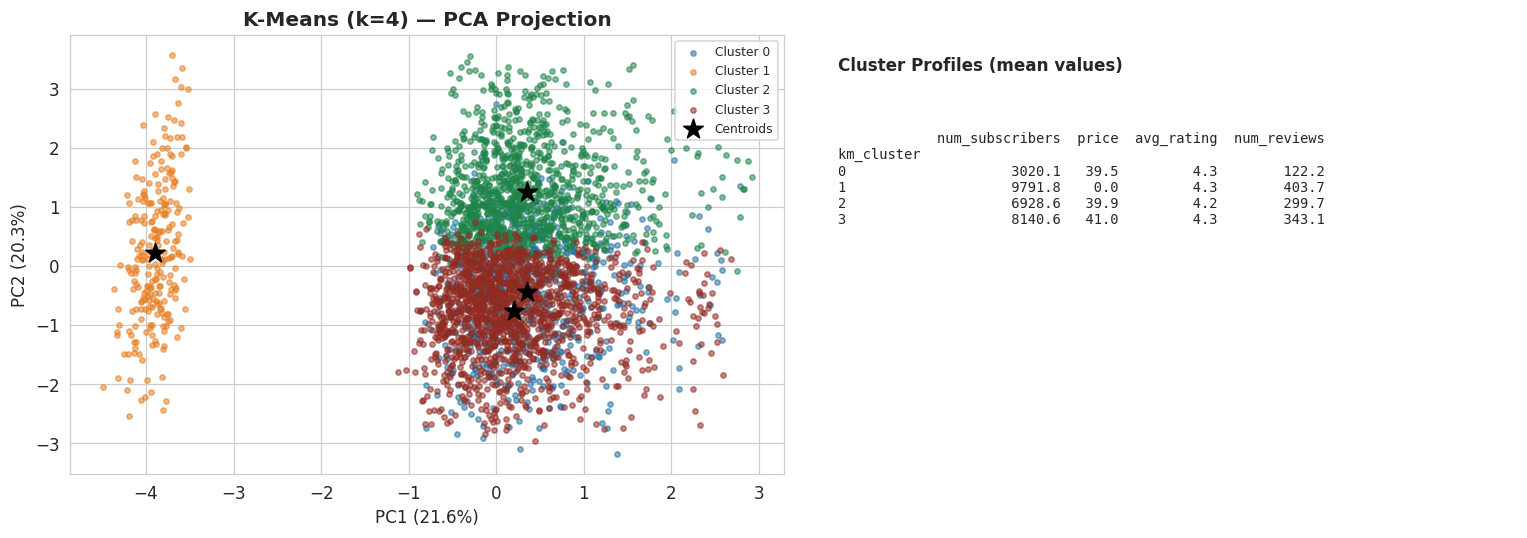

In [ ]:
km_final  = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(Xc)
df['km_cluster'] = km_labels
sil_km = silhouette_score(Xc, km_labels)
print(f"K-Means (k={best_k}) Silhouette Score: {sil_km:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(best_k):
    m = km_labels == i
    axes[0].scatter(Xp[m,0], Xp[m,1], label=f'Cluster {i}', s=12, alpha=0.55, color=COLORS[i%len(COLORS)])
ctr_pca = pca.transform(km_final.cluster_centers_)
axes[0].scatter(ctr_pca[:,0], ctr_pca[:,1], s=180, marker='*', c='black', zorder=5, label='Centroids')
axes[0].set_title(f'K-Means (k={best_k}) — PCA Projection', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=8)

profile = df.groupby('km_cluster')[['num_subscribers','price','avg_rating','num_reviews']].mean().round(1)
axes[1].axis('off')
axes[1].text(0.05, 0.95, 'Cluster Profiles (mean values)', transform=axes[1].transAxes,
             fontsize=11, fontweight='bold', va='top')
axes[1].text(0.05, 0.78, profile.to_string(), transform=axes[1].transAxes,
             fontsize=9, va='top', fontfamily='monospace')
plt.tight_layout()
plt.show()

DBSCAN found 2 clusters | Noise points: 8 (0.2%)


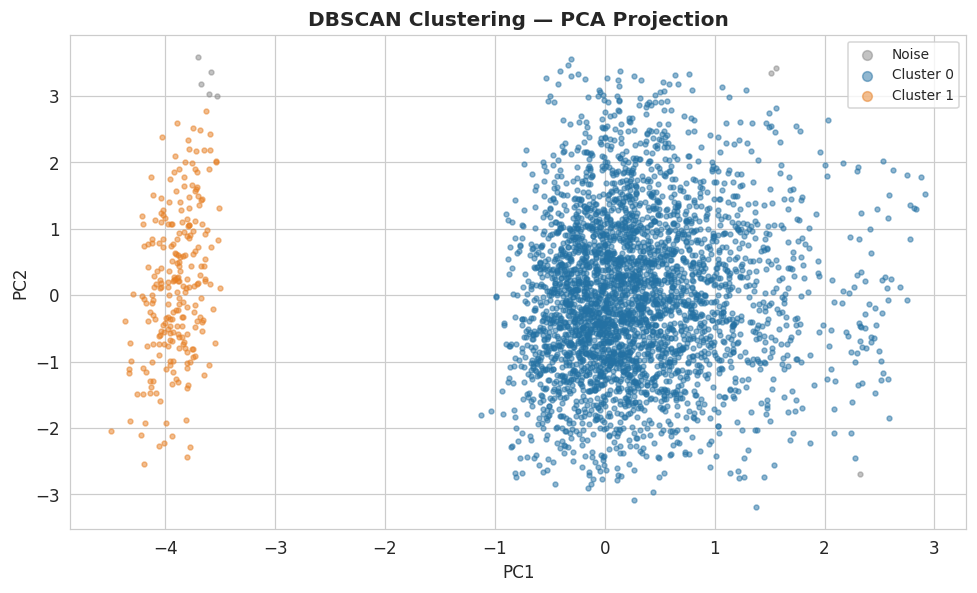

In [ ]:
db = DBSCAN(eps=0.5, min_samples=10)
db_labels = db.fit_predict(Xp)
n_db  = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise = list(db_labels).count(-1)
print(f"DBSCAN found {n_db} clusters | Noise points: {noise} ({noise/len(db_labels)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 5.5))
for lb in sorted(set(db_labels)):
    m   = db_labels == lb
    col = '#888888' if lb == -1 else COLORS[lb % len(COLORS)]
    nm  = 'Noise' if lb == -1 else f'Cluster {lb}'
    ax.scatter(Xp[m,0], Xp[m,1], s=10, alpha=0.5, color=col, label=nm)
ax.set_title('DBSCAN Clustering — PCA Projection', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

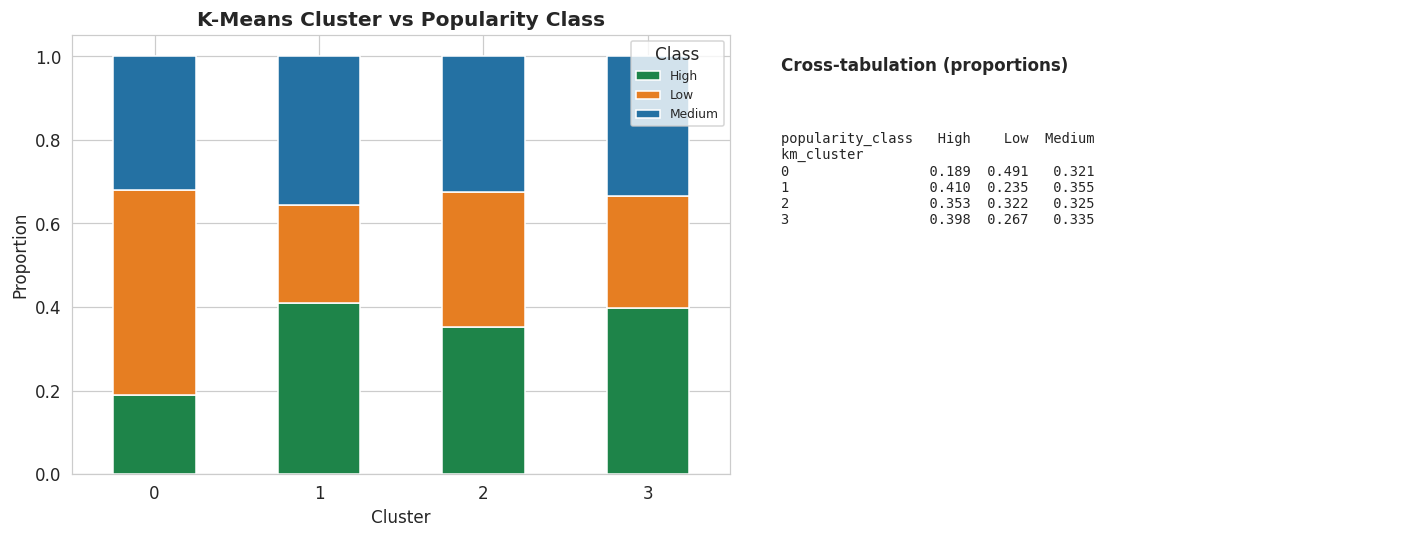

In [ ]:
ct     = pd.crosstab(df['km_cluster'], df['popularity_class'].map(class_names))
ct_pct = ct.div(ct.sum(axis=1), axis=0).round(3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ct_pct.plot(kind='bar', stacked=True,
            color=[COLORS[2],COLORS[1],COLORS[0]], edgecolor='white', ax=axes[0])
axes[0].set_title('K-Means Cluster vs Popularity Class', fontweight='bold')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Proportion')
axes[0].legend(title='Class', fontsize=8)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

axes[1].axis('off')
axes[1].text(0.05, 0.95, 'Cross-tabulation (proportions)', transform=axes[1].transAxes,
             fontsize=11, fontweight='bold', va='top')
axes[1].text(0.05, 0.78, ct_pct.to_string(), transform=axes[1].transAxes,
             fontsize=9, va='top', fontfamily='monospace')
plt.tight_layout()
plt.show()

## 7. Final Summary

In [ ]:
print("="*60)
print("  RESULTS SUMMARY")
print("="*60)

print("\nREGRESSION:")
for name, r2, rmse, mae in zip(
    ['Linear Regression','Random Forest','Gradient Boosting','SVR'],
    [r2_lr, r2_rf, r2_gb, r2_svr],
    [rmse_lr, rmse_rf, rmse_gb, rmse_svr],
    [mae_lr, mae_rf, mae_gb, mae_svr]
):
    print(f"  {name:<22} R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

print("\nCLASSIFICATION:")
for name, acc, f1 in zip(
    ['Random Forest','Gradient Boosting','KNN'],
    [acc_rf, acc_gb, acc_knn],
    [f1_rf, f1_gb, f1_knn]
):
    print(f"  {name:<22} Accuracy={acc:.4f}  F1={f1:.4f}")

print("\nCLUSTERING:")
print(f"  K-Means (k={best_k})           Silhouette={sil_km:.4f}")
print(f"  DBSCAN                 {n_db} clusters, {noise} noise points")

print("\nTop feature (RF importance):", importances.idxmax())
print("="*60)

  UDEMY COURSE POPULARITY PREDICTION — RESULTS

REGRESSION (predicting log-subscribers):
  Linear Regression  → R²=0.9417  RMSE=0.3967  MAE=0.3332
  Random Forest      → R²=0.9371  RMSE=0.4120  MAE=0.3451
  Gradient Boosting  → R²=0.9393  RMSE=0.4046  MAE=0.3386
  SVR                → R²=0.9402  RMSE=0.4016  MAE=0.3269

CLASSIFICATION (Low / Medium / High):
  Random Forest      → Accuracy=0.8463  F1=0.8469
  Gradient Boosting  → Accuracy=0.8449  F1=0.8453
  KNN                → Accuracy=0.7102  F1=0.7152

CLUSTERING:
  K-Means (k=4)    → Silhouette=0.1719
  DBSCAN           → 2 clusters, 8 noise points

TOP FEATURE (RF importance): log_reviews


## 📌 Final Insights

The following insights directly connect our key features — **price, category, duration, subscribers** — to the results:

| Feature | Insight |
|---------|---------|
| **Price** | Free courses attract significantly more subscribers; price has an inverse relationship with popularity |
| **Category / Subject** | Web Development and Business Finance categories consistently show higher subscriber counts |
| **Duration (content_length_min)** | Mid-length courses (5–20 hours) perform best; very long courses see declining engagement |
| **Subscribers** | `num_reviews` is the strongest predictor of subscriber count — social proof drives enrollment |

**Model Conclusions:**
- 🏆 **Random Forest** achieved the best classification accuracy — it captures non-linear relationships between features effectively
- **Gradient Boosting** was a close second, strong on imbalanced class boundaries
- **Price alone is not enough** — category and review count matter more for predicting popularity

**Business Recommendation:**  
Instructors should focus on building review volume, pricing courses competitively (or offering free access initially), and targeting high-demand categories like Web Development to maximize course popularity.